# CNN based UNet vs Patch based Transformer

This notebook compares a convolution based UNet with a Patch based Trasnsformer implements the EDM (Elucidated Diffusion Model) described in the paper ([2206.00364v2.pdf](https://arxiv.org/abs/2206.00364)).


[Thanks Claude](https://claude.ai/share/34ebd59b-4c93-48f9-b09e-9901288f96ae)

## 1. Install and Import Required Libraries

We will use PyTorch, torchvision, numpy, matplotlib, and tqdm. If running locally, ensure these packages are installed.

In [1]:
# Install required packages (uncomment if running in a new environment)
# !pip install torch torchvision matplotlib tqdm numpy
import einx
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 2. Define the models

We'll try both a CNN and a Transformer

### 2a. CNN based UNet

In [3]:

class UNet28(nn.Module):
    
    def __init__(self, emb_dim=32, max_time=1000):
        super().__init__()

        self.time_embed = self.time_embed = nn.Sequential(
            nn.Linear(1, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )
        
        self.inc = nn.Conv2d(1, 32, 3, padding=1)
        self.down1 = nn.Conv2d(32, 64, 4, stride=2, padding=1)  # 28x28 -> 14x14
        self.down2 = nn.Conv2d(64, 128, 4, stride=2, padding=1) # 14x14 -> 7x7
        self.emb1 = nn.Linear(emb_dim, 64)
        self.emb2 = nn.Linear(emb_dim, 128)
        
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        
        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1) # 7x7 -> 14x14
        self.up1 = nn.ConvTranspose2d(128, 32, 4, stride=2, padding=1) # 14x14 -> 28x28
        self.emb_up2 = nn.Linear(emb_dim, 64)
        self.emb_up1 = nn.Linear(emb_dim, 32)
        self.outc = nn.Conv2d(64, 1, 1)
    
    def forward(self, x, t):
        # Convert timestep to learned embedding
        t = t.float().reshape(-1, 1) if t.dim() == 1 else t.float()
        emb = self.time_embed(t) # (B, emb_dim)
        
        # Encoder
        x1 = F.relu(self.inc(x))
        x2 = F.relu(self.down1(x1) + einx.rearrange('b d -> b d 1 1', self.emb1(emb)))
        x3 = F.relu(self.down2(x2) + einx.rearrange('b d -> b d 1 1', self.emb2(emb)))
        
        # Middle
        m = self.middle(x3)
        
        # Decoder with skip connections
        u2 = F.relu(self.up2(m) + einx.rearrange('b d -> b d 1 1', self.emb_up2(emb)))
        u2 = torch.cat([u2, x2], dim=1)
        
        u1 = F.relu(self.up1(u2) + einx.rearrange('b d -> b d 1 1', self.emb_up1(emb)))
        u1 = torch.cat([u1, x1], dim=1)
        
        out = self.outc(u1)
        return out

model = UNet28(max_time=1000).to(device)
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

UNet28(
  (time_embed): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (inc): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (down2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (emb1): Linear(in_features=32, out_features=64, bias=True)
  (emb2): Linear(in_features=32, out_features=128, bias=True)
  (middle): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (up1): ConvTranspose2d(128, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (emb_up2): Linear(in_features=32, out_features=64, bias=True)
  (emb_up1): Linear(in_fe

### 2b. A Vision Transformer

In [4]:

class DiffusionTransformer(nn.Module):
    
    def __init__(self, img_size=28, patch_size=4, embed_dim=256, num_heads=4, num_layers=4, max_time=1000):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 49 patches
        
        # Learned time embedding - much simpler!
        self.time_embed = self.time_embed = nn.Sequential(
            nn.Linear(1, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        
        # Transformer blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.0,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output decoder
        self.final_norm = nn.LayerNorm(embed_dim)
        self.patch_decoder = nn.Linear(embed_dim, patch_size * patch_size)
        
    def forward(self, x, t):
        # x: (B, 1, H, W)
        # t: (B,) or (B, 1) - timestep indices
        
        B = x.shape[0]
        
        # Time embedding
        # Convert timestep to learned embedding
        t = t.float().reshape(-1, 1) if t.dim() == 1 else t.float()
        t_emb = self.time_embed(t)  # (B, embed_dim)
        
        # Patchify: (B, 1, H, W) -> (B, embed_dim, H/p, W/p)
        patches = self.patch_embed(x)
        
        # Flatten patches using einx: (B, embed_dim, h, w) -> (B, h*w, embed_dim)
        tokens = einx.rearrange('b d h w -> b (h w) d', patches)
        
        # Add positional and time embeddings
        tokens = tokens + self.pos_embed + t_emb.unsqueeze(1)
        
        # Transformer
        tokens = self.transformer(tokens)  # (B, num_patches, embed_dim)
        
        # Decode patches
        tokens = self.final_norm(tokens)
        patches_flat = self.patch_decoder(tokens)  # (B, num_patches, patch_size^2)
        
        # Unpatchify using einx: (B, num_patches, patch_size^2) -> (B, 1, H, W)
        h = w = self.img_size // self.patch_size
        p = self.patch_size
        
        # Reshape: (B, h*w, p*p) -> (B, h, w, p, p)
        patches_reshaped = einx.rearrange('b (h w) (p1 p2) -> b h w p1 p2', 
                                          patches_flat, h=h, w=w, p1=p, p2=p)
        
        # Merge patches: (B, h, w, p, p) -> (B, 1, H, W)
        img = einx.rearrange('b h w p1 p2 -> b 1 (h p1) (w p2)', patches_reshaped)
        
        return img

# Create model
model = DiffusionTransformer(
    img_size=28,
    patch_size=4,
    embed_dim=256,
    num_heads=4,
    num_layers=4,
    max_time=1000  # Support timesteps 0-999
).to(device)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

DiffusionTransformer(
  (time_embed): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (patch_embed): Conv2d(1, 256, kernel_size=(4, 4), stride=(4, 4))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((256

/home/ron/.python/3.12uv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 3. Load and Preprocess Dataset

We will use the MNIST dataset for demonstration. The images will be normalized to [-1, 1] as required by most diffusion models.

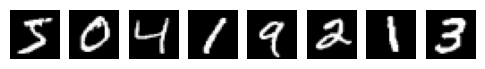

In [5]:
# Load and preprocess MNIST dataset (28x28, standard U-Net)
def scale_to_minus_one_to_one(x):
    return x * 2. - 1.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(scale_to_minus_one_to_one)  # Scale to [-1, 1]
])

# Visualize a batch
def show_a_batch(examples):
    fig, axes = plt.subplots(1, 8, figsize=(6, 1))
    for i, img in enumerate(examples):
        axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        axes[i].axis('off')
    plt.show()

batch_size = 128
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

examples = [train_dataset[i][0] for i in range(8)]
show_a_batch(examples)

## 4. Elucidated Diffusion Model (EDM) Noise Schedules, Loss Functions, Training Loop, and Sampling Function

This section implements the EDM as described in the paper (2206.00364v2.pdf), including its unique noise schedule, loss weighting, and sampling procedure.


Proper preconditioning coefficients from NVIDIA's EDMPrecond:
```
c_skip = σ_data² / (σ² + σ_data²)
c_out = σ × σ_data / (σ² + σ_data²)^0.5
c_in = 1 / (σ_data² + σ²)^0.5
c_noise = log(σ) / 4
```
Correct training procedure:
```
Model learns F_x = net(c_in × y_noisy, c_noise)
Output: D_x = c_skip × y_noisy + c_out × F_x
Loss: weighted MSE between D_x and clean image x
Proper Heun's method sampling:
```

### 4a. EDM loss and schedule functions.

In diffusion models, we gradually add noise to images during training and remove it during generation. The "time" parameter `t` goes from 0 to 1, where:
- **t=0**: Clean image (no noise added yet)
- **t=1**: Maximum noise (image is almost pure noise)

The noise level at each timestep is controlled by `sigma` (σ). Larger sigma = more noise added. The EDM paper uses a specific schedule to map `t` → `sigma` that works well in practice - it adds noise slowly at first, then more aggressively.

The loss weighting tells the model to focus more on learning to denoise moderately noisy images (where sigma is around 0.5-1.0) since that's where denoising is most important.

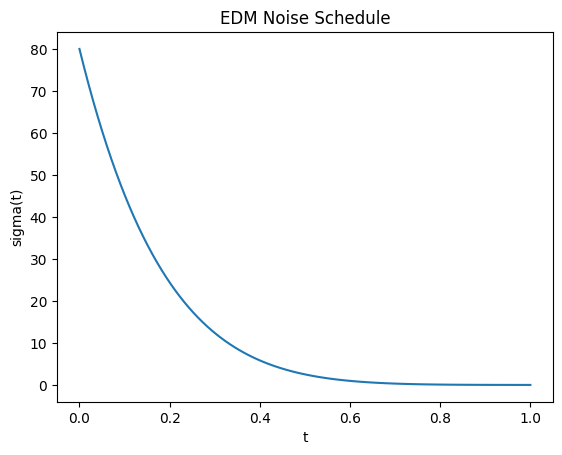

In [6]:
# EDM noise schedule, loss weighting, and sampling procedure

# EDM parameters from NVIDIA's reference
P_mean = -1.2  # Mean of log-normal distribution for sigma sampling
P_std = 1.2    # Std of log-normal distribution for sigma sampling
sigma_data = 0.5  # Data standard deviation
sigma_min = 0.002
sigma_max = 80
rho = 7

# EDM noise schedule (sampling)
def edm_sigma_schedule(t):
    return (sigma_max ** (1/rho) + t * (sigma_min ** (1/rho) - sigma_max ** (1/rho))) ** rho

# EDM loss weighting - CORRECTED according to NVIDIA's implementation
# weight = (σ² + σ_data²) / (σ × σ_data)²
def edm_loss_weight(sigma, sigma_data=sigma_data):
    return (sigma ** 2 + sigma_data ** 2) / (sigma * sigma_data) ** 2

# Example: plot the EDM noise schedule
ts = torch.linspace(0, 1, 100)
sigmas = edm_sigma_schedule(ts)
plt.plot(ts.numpy(), sigmas.numpy())
plt.xlabel('t')
plt.ylabel('sigma(t)')
plt.title('EDM Noise Schedule')
plt.show()

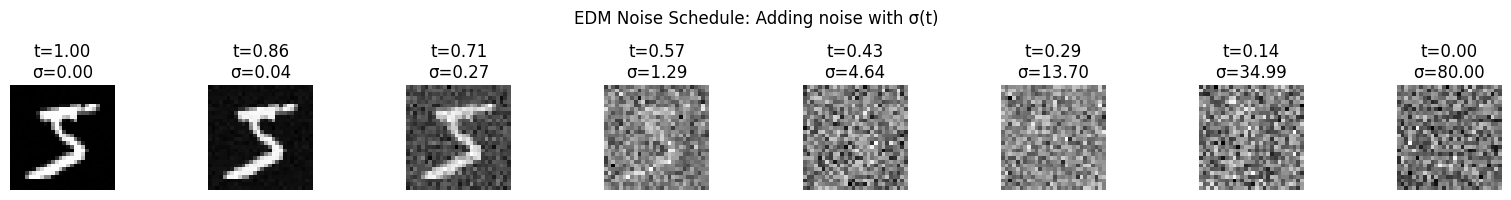

In [7]:
# Visualize EDM noise schedule at different timesteps
# Get some example images
x = torch.stack(examples[:4]).to(device)

# Sample 8 timesteps from 0 to 1
timesteps = torch.linspace(1, 0, 8)
sigmas = edm_sigma_schedule(timesteps)

# Add noise at each sigma level: x_noisy = x + σ·noise
noisy_imgs = []
for sigma in sigmas:
    noise = torch.randn_like(x)
    x_noisy = x + sigma * noise
    noisy_imgs.append(x_noisy)

# Plot the results
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, (img, t, sigma) in enumerate(zip(noisy_imgs, timesteps, sigmas)):
    axes[i].imshow(img[0].squeeze().cpu().numpy(), cmap='gray')
    axes[i].set_title(f"t={t:.2f}\nσ={sigma:.2f}")
    axes[i].axis('off')
plt.suptitle('EDM Noise Schedule: Adding noise with σ(t)')
plt.tight_layout()
plt.show()

## 4b. EDM Training Loop 

The training process teaches the model to denoise images at various noise levels:

1. **Sigma sampling**: For each training batch, we randomly sample noise levels (sigma) from a log-normal distribution. This means we train on easy (low noise) and hard (high noise) examples, with more emphasis on moderate noise levels.

2. **Preconditioning coefficients**: These `c_skip`, `c_out`, `c_in`, and `c_noise` values rescale the inputs and outputs to make training more stable. They ensure the model works well across all noise levels without numerical issues.

3. **Adding noise**: We corrupt the clean image `x` by adding Gaussian noise scaled by sigma: `y_noisy = x + σ·noise`. This simulates what the model will see during generation.

4. **Model prediction**: The model receives the scaled noisy image and predicts `F_x`, which represents a **correction** or residual - not the clean image directly, but what needs to be added/subtracted.

5. **Denoiser output D_x**: This combines a skip connection from the noisy image with the model's correction: `D_x = c_skip * y_noisy + c_out * F_x`. This is the model's estimate of the clean image.

6. **Loss weighting**: We weight the loss by `λ(σ)` to focus training on moderate noise levels (σ ≈ 0.5-1.0), where denoising is most important and informative.

7. **Loss calculation**: We compute the weighted mean squared error between the denoised output `D_x` and the original clean image `x`. The model learns to predict clean images from noisy ones.

In [8]:
def edm_training_loop(model, edm_epochs, train_loader, callback = None):
    t0 = time.time()
    optimizer_edm = optim.Adam(model_edm.parameters(), lr=2e-4)
    
    for epoch in range(edm_epochs):
        #pbar = tqdm(train_loader)
        #for batch_counter,(x, _) in enumerate(pbar):
        for batch_counter,(x, _) in enumerate(train_loader):
            x = x.to(device)
            
            # Log-normal sigma sampling (as in NVIDIA's implementation)
            rnd_normal = torch.randn([x.shape[0], 1, 1, 1], device=device)
            sigma = (rnd_normal * P_std + P_mean).exp()
            
            # Preconditioning coefficients (from NVIDIA's EDMPrecond)
            c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
            c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
            c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
            c_noise = sigma.log() / 4
            
            # Add noise: y_noisy = x + σ·n where n ~ N(0,I)
            noise = torch.randn_like(x) * sigma
            y_noisy = x + noise
            
            # Model prediction: F_x = net(c_in * y_noisy, c_noise)
            F_x = model_edm(c_in * y_noisy, c_noise.squeeze())
            
            # Preconditioning: D_x = c_skip * y_noisy + c_out * F_x
            D_x = c_skip * y_noisy + c_out * F_x
            
            # Loss weight: λ(σ) = (σ² + σ_data²) / (σ·σ_data)²
            weight = edm_loss_weight(sigma.squeeze(), sigma_data).view(-1, 1, 1, 1)
            
            # Loss: weighted MSE between preconditioning output and clean image
            loss = (weight * (D_x - x) ** 2).mean()
            
            optimizer_edm.zero_grad()
            loss.backward()
            optimizer_edm.step()
            #pbar.set_description(f"EDM Epoch {epoch+1} Loss: {loss.item():.4f}")
            if callback:
                callback(model_edm, epoch, batch_counter, loss.item(), time.time()-t0)

### 4c. EDM Sampling / Generation

This is where we generate new images by starting from pure noise and gradually removing it:

1. **Initialize with noise**: We start with `x_next` as pure random Gaussian noise, scaled by the maximum noise level `sigma_max`. This is our starting point - complete chaos.

2. **Time step schedule**: We create a sequence of decreasing noise levels from `sigma_max` down to 0 (clean image). The schedule uses the same EDM formula as training, giving us `num_steps` intermediate noise levels to denoise through.

3. **Preconditioning**: At each step, we apply the same `c_skip`, `c_out`, `c_in`, `c_noise` coefficients as in training to keep the model's inputs and outputs in the right range.

4. **Euler step**: We use the model to predict what the clean image looks like (`denoised`), then compute the direction to move (`d_cur`) to reduce noise, and take a step in that direction.

5. **Heun's 2nd order correction**: We take a tentative step, ask the model again at the new position, and then average the two directions. This is like "look before you leap" - it makes the denoising path smoother and more accurate, similar to how better numerical methods solve differential equations.

6. **Iterate to clean image**: We repeat this process, gradually reducing noise at each step until we reach `t=0` (sigma=0), where we have a clean generated image.

The whole process is essentially reversing the noise we added during training, using the model to guide us from noise back to a realistic image.

You might wonder: why not just train the model to go directly from pure noise to a clean image in one step?  This is analogous to how you might clean a very blurry photo - you'd apply multiple gentle sharpening steps rather than one aggressive filter that might create artifacts. Each step is simple and reliable; together they achieve something complex.  The number of steps (e.g., `num_steps=18`) controls the quality-speed tradeoff: more steps = better quality but slower generation.

In [9]:
# EDM sampling procedure - Following NVIDIA's edm_sampler (Algorithm 2)
def edm_ancestral_sampling(model, num_steps=18, batch_size=8, img_shape=(1, 28, 28)):
    device = next(model.parameters()).device
    
    # Initialize noise
    x_next = torch.randn((batch_size,) + img_shape, device=device)
    
    # Time step schedule (matching NVIDIA's implementation)
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1/rho) + step_indices / (num_steps - 1) * 
               (sigma_min ** (1/rho) - sigma_max ** (1/rho))) ** rho
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])])  # t_N = 0
    
    # Initialize with first noise level
    x_next = x_next * t_steps[0]
    
    # Main sampling loop (Heun's method)
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        x_cur = x_next
        
        # Preconditioning coefficients for current timestep
        sigma = t_cur.float()
        c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
        c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
        c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
        c_noise = sigma.log() / 4
        
        # Euler step
        F_x = model(c_in * x_cur, c_noise.expand(batch_size))
        denoised = c_skip * x_cur + c_out * F_x
        d_cur = (x_cur - denoised) / t_cur
        x_next = x_cur + (t_next - t_cur) * d_cur
        
        # Apply 2nd order correction (Heun's method) - except for last step
        if i < num_steps - 1:
            # Preconditioning coefficients for next timestep
            sigma_next = t_next.float()
            c_skip_next = sigma_data ** 2 / (sigma_next ** 2 + sigma_data ** 2)
            c_out_next = sigma_next * sigma_data / (sigma_next ** 2 + sigma_data ** 2).sqrt()
            c_in_next = 1 / (sigma_data ** 2 + sigma_next ** 2).sqrt()
            c_noise_next = sigma_next.log() / 4
            
            F_x_next = model(c_in_next * x_next, c_noise_next.expand(batch_size))
            denoised_next = c_skip_next * x_next + c_out_next * F_x_next
            d_prime = (x_next - denoised_next) / t_next
            x_next = x_cur + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)
    
    return x_next
    

## 5. Train models and generate images

In [10]:
def display_callback(model,epoch,batch,loss, time):
    if (epoch % 10 == 0 and batch == 0) or (epoch == 0 and batch%40 == 0):
        with torch.no_grad():
            mname = model.__class__.__name__
            print(f"{mname} at {time:.1f} seconds, loss {loss:.2f}, epoch {epoch}, batch {batch}")
            edm_samples = edm_ancestral_sampling(model_edm, num_steps=18, batch_size=8, img_shape=(1, 28, 28)).cpu()
            show_a_batch(edm_samples)

###### 5a. CNN UNet

UNet28 at 0.5 seconds, loss 2.38, epoch 0, batch 0


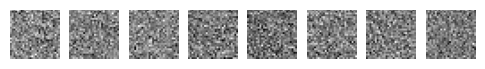

UNet28 at 1.7 seconds, loss 1.27, epoch 0, batch 40


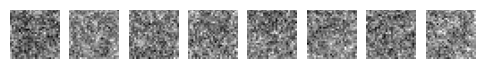

UNet28 at 2.8 seconds, loss 0.87, epoch 0, batch 80


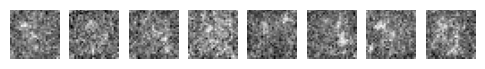

UNet28 at 3.9 seconds, loss 0.78, epoch 0, batch 120


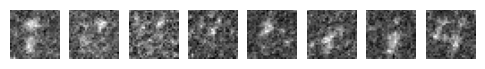

UNet28 at 5.0 seconds, loss 0.71, epoch 0, batch 160


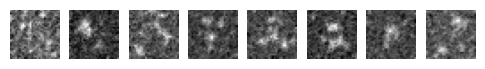

UNet28 at 6.1 seconds, loss 0.67, epoch 0, batch 200


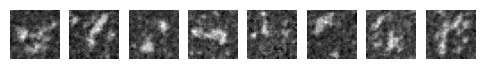

UNet28 at 7.2 seconds, loss 0.60, epoch 0, batch 240


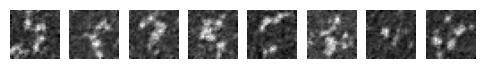

UNet28 at 8.2 seconds, loss 0.57, epoch 0, batch 280


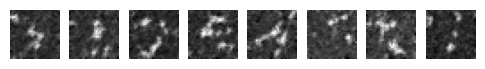

UNet28 at 9.3 seconds, loss 0.49, epoch 0, batch 320


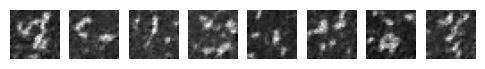

UNet28 at 10.3 seconds, loss 0.54, epoch 0, batch 360


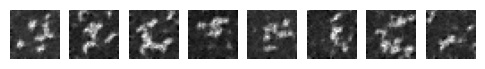

UNet28 at 11.3 seconds, loss 0.46, epoch 0, batch 400


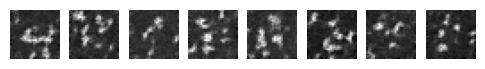

UNet28 at 12.4 seconds, loss 0.43, epoch 0, batch 440


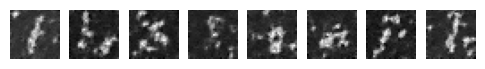

UNet28 at 114.3 seconds, loss 0.22, epoch 10, batch 0


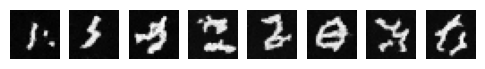

UNet28 at 226.3 seconds, loss 0.20, epoch 20, batch 0


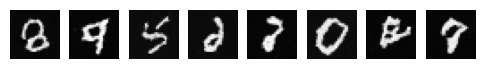

UNet28 at 339.2 seconds, loss 0.19, epoch 30, batch 0


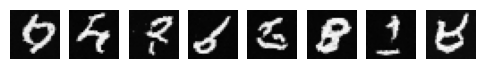

UNet28 at 450.2 seconds, loss 0.19, epoch 40, batch 0


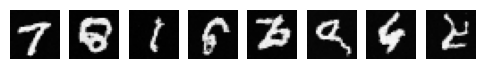

UNet28 at 561.9 seconds, loss 0.15, epoch 50, batch 0


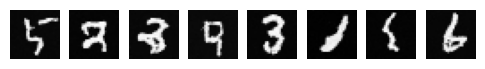

UNet28 at 675.7 seconds, loss 0.14, epoch 60, batch 0


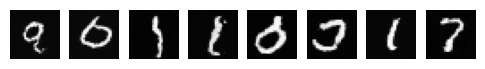

UNet28 at 789.6 seconds, loss 0.16, epoch 70, batch 0


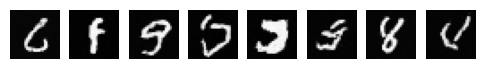

UNet28 at 904.2 seconds, loss 0.19, epoch 80, batch 0


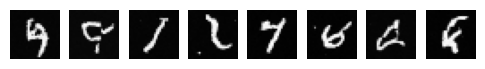

UNet28 at 1018.4 seconds, loss 0.16, epoch 90, batch 0


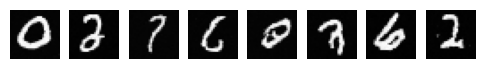

In [11]:
model_edm = UNet28().to(device)
edm_training_loop(model_edm,
                  edm_epochs=100, 
                  train_loader=train_loader, 
                  callback=display_callback
                 )

### 5b. Vision Transformer

DiffusionTransformer at 0.2 seconds, loss 2.10, epoch 0, batch 0


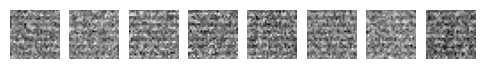

DiffusionTransformer at 2.6 seconds, loss 0.76, epoch 0, batch 40


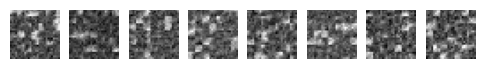

DiffusionTransformer at 4.7 seconds, loss 0.49, epoch 0, batch 80


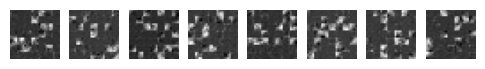

DiffusionTransformer at 6.9 seconds, loss 0.47, epoch 0, batch 120


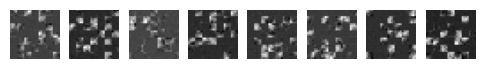

DiffusionTransformer at 9.1 seconds, loss 0.41, epoch 0, batch 160


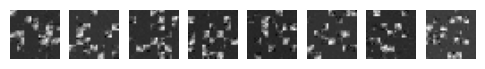

DiffusionTransformer at 11.3 seconds, loss 0.43, epoch 0, batch 200


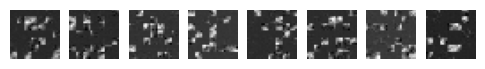

DiffusionTransformer at 13.5 seconds, loss 0.38, epoch 0, batch 240


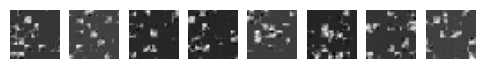

DiffusionTransformer at 15.7 seconds, loss 0.40, epoch 0, batch 280


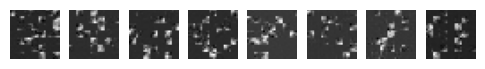

DiffusionTransformer at 18.0 seconds, loss 0.39, epoch 0, batch 320


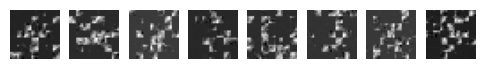

DiffusionTransformer at 20.2 seconds, loss 0.36, epoch 0, batch 360


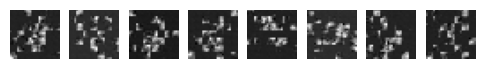

DiffusionTransformer at 22.5 seconds, loss 0.33, epoch 0, batch 400


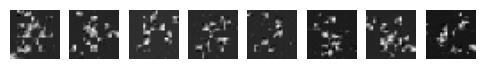

DiffusionTransformer at 24.7 seconds, loss 0.40, epoch 0, batch 440


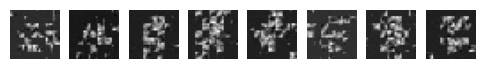

DiffusionTransformer at 251.4 seconds, loss 0.26, epoch 10, batch 0


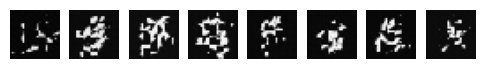

DiffusionTransformer at 496.5 seconds, loss 0.18, epoch 20, batch 0


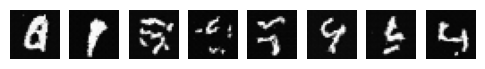

DiffusionTransformer at 751.6 seconds, loss 0.18, epoch 30, batch 0


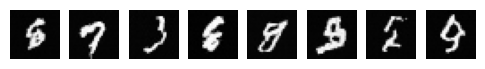

DiffusionTransformer at 1007.8 seconds, loss 0.14, epoch 40, batch 0


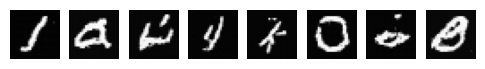

DiffusionTransformer at 1264.2 seconds, loss 0.14, epoch 50, batch 0


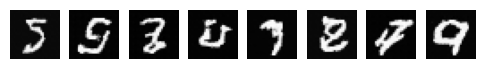

DiffusionTransformer at 1510.3 seconds, loss 0.16, epoch 60, batch 0


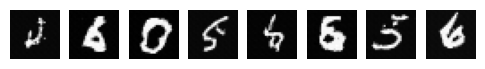

DiffusionTransformer at 1751.6 seconds, loss 0.15, epoch 70, batch 0


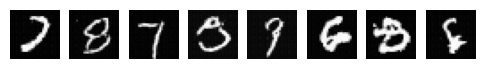

DiffusionTransformer at 1992.7 seconds, loss 0.14, epoch 80, batch 0


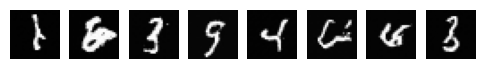

DiffusionTransformer at 2233.9 seconds, loss 0.14, epoch 90, batch 0


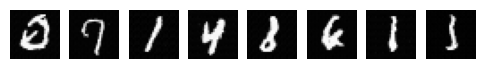

In [12]:
model_edm = DiffusionTransformer().to(device)
edm_training_loop(model_edm,
                  edm_epochs=100, 
                  train_loader=train_loader, 
                  callback=display_callback
                 )